In [ ]:

# ============================================================
# PROJECT: South African Equity Risk Modeling
# CAPM + Monte Carlo + Value at Risk
# Author: Nicholas Nhlapo
# ============================================================

# Install yfinance inside the Colab environment
# This allows us to download financial market data
!pip install yfinance

In [ ]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import yfinance as yf              # Used to download stock data
import pandas as pd                # Used for data tables
import numpy as np                 # Used for numerical calculations
import matplotlib.pyplot as plt    # Used for plotting graphs
from sklearn.linear_model import LinearRegression  # Used for regression

In [ ]:

# ============================================================
# CELL 3: DEFINE STOCK AND MARKET INDEX
# ============================================================

# Define the stock ticker for Naspers on the JSE
stock_ticker = "NPN.JO"

# Define the market index ticker for FTSE/JSE Top 40
market_ticker = "^JN0U.JO"

print("Stock selected:", stock_ticker)
print("Market index selected:", market_ticker)

Stock selected: NPN.JO
Market index selected: ^JN0U.JO


In [ ]:

# ============================================================
# CELL 4: DOWNLOAD HISTORICAL DATA
# ============================================================

# Download 5 years of daily historical data for the stock
stock_data = yf.download(stock_ticker, start="2021-02-01", end="2026-02-01")

# Download 5 years of daily historical data for the market index
market_data = yf.download(market_ticker, start="2021-02-01", end="2026-02-01")

# Display first few rows to confirm data loaded correctly
print("Stock Data Preview:")
print(stock_data.head())

print("\nMarket Data Preview:")
print(market_data.head())

/tmp/ipython-input-2154049190.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_ticker, start="2021-02-01", end="2026-02-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2154049190.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(market_ticker, start="2021-02-01", end="2026-02-01")
[*********************100%***********************]  1 of 1 completed

Stock Data Preview:
Price              Close          High           Low          Open   Volume
Ticker            NPN.JO        NPN.JO        NPN.JO        NPN.JO   NPN.JO
Date                                                                       
2021-02-01  70638.921875  72693.802738  70638.921875  72189.678674  5979830
2021-02-02  71288.828125  72389.054143  70978.673605  72448.646367  4635530
2021-02-03  71828.734375  72618.407398  71424.594635  71788.740648  5234095
2021-02-04  71925.335938  72523.640663  71245.442429  72211.892617  4820765
2021-02-05  71355.812500  72568.419257  70804.500500  72568.622350  4608270

Market Data Preview:
Price             Close         High          Low         Open   Volume
Ticker         ^JN0U.JO     ^JN0U.JO     ^JN0U.JO     ^JN0U.JO ^JN0U.JO
Date                                                                   
2021-02-01  4111.220215  4165.419922  4083.469971  4083.979980        0
2021-02-02  4128.759766  4178.259766  4109.680176  4127.359863

In [ ]:
# ============================================================
# CELL 5: CALCULATE DAILY RETURNS
# ============================================================

# Extract adjusted closing prices
stock_prices = stock_data["Close"]
market_prices = market_data["Close"]

# Calculate daily percentage returns
# pct_change computes (P_t - P_t-1) / P_t-1
stock_returns = stock_prices.pct_change()

market_returns = market_prices.pct_change()

# Remove missing values created by first difference
stock_returns = stock_returns.dropna()
market_returns = market_returns.dropna()

# Combine both return series into one DataFrame
returns = pd.concat([stock_returns, market_returns], axis=1)

# Rename columns for clarity
returns.columns = ["Stock", "Market"]

# Remove any remaining missing values
returns = returns.dropna()

print("Returns Preview:")
print(returns.head())

Returns Preview:
               Stock    Market
Date                          
2021-02-02  0.009200  0.004266
2021-02-03  0.007574  0.004982
2021-02-04  0.001345  0.004046
2021-02-05 -0.007918  0.020247
2021-02-08  0.006067  0.014747


In [ ]:
# ============================================================
# CELL 6: ESTIMATE BETA USING LINEAR REGRESSION
# ============================================================

# Reshape market returns into 2D array for regression input
X = returns["Market"].values.reshape(-1, 1)

# Stock returns are the dependent variable
y = returns["Stock"].values

# Create linear regression model
model = LinearRegression()

# Fit model to historical data
model.fit(X, y)

# Extract beta coefficient
beta = model.coef_[0]

# Extract alpha
alpha = model.intercept_

print("Estimated Beta:", beta)
print("Estimated Alpha:", alpha)

Estimated Beta: 0.7684487595112585
Estimated Alpha: 0.00015849425683851743


In [ ]:
# ============================================================
# CELL 7: CALCULATE EXPECTED RETURN USING CAPM
# ============================================================

# Approximate South African risk free rate
risk_free_rate = 0.08  # 8 percent

# Calculate annualized average market return
# Multiply daily mean return by 252 trading days
market_return = returns["Market"].mean() * 252

# Apply CAPM formula
expected_return = risk_free_rate + beta * (market_return - risk_free_rate)

print("Annualized Market Return:", market_return)
print("Expected Annual Return (CAPM):", expected_return)

Annualized Market Return: 0.15483931888929153
Expected Annual Return (CAPM): 0.13751018176314356


In [ ]:
# ============================================================
# CELL 8: MONTE CARLO SIMULATION
# ============================================================

# Current stock price
S0 = stock_prices.iloc[-1].item() # Convert Series to scalar

# Annualized volatility
volatility = returns["Stock"].std() * np.sqrt(252)

# Simulation parameters
T = 1              # 1 year
dt = 1 / 252       # Daily step
N = int(T / dt)    # Number of steps
simulations = 100  # Number of simulated paths

# Create empty matrix to store simulation results
price_paths = np.zeros((N, simulations))

# Run Monte Carlo simulation
for i in range(simulations):

    prices = [S0]  # Start each simulation at current price

    for t in range(1, N):

        # Drift component of Geometric Brownian Motion
        drift = (expected_return - 0.5 * volatility**2) * dt

        # Random shock component
        shock = volatility * np.sqrt(dt) * np.random.normal()

        # GBM price update formula
        price = prices[-1] * np.exp(drift + shock)

        prices.append(price)

    price_paths[:, i] = prices

print("Simulation completed.")

Simulation completed.


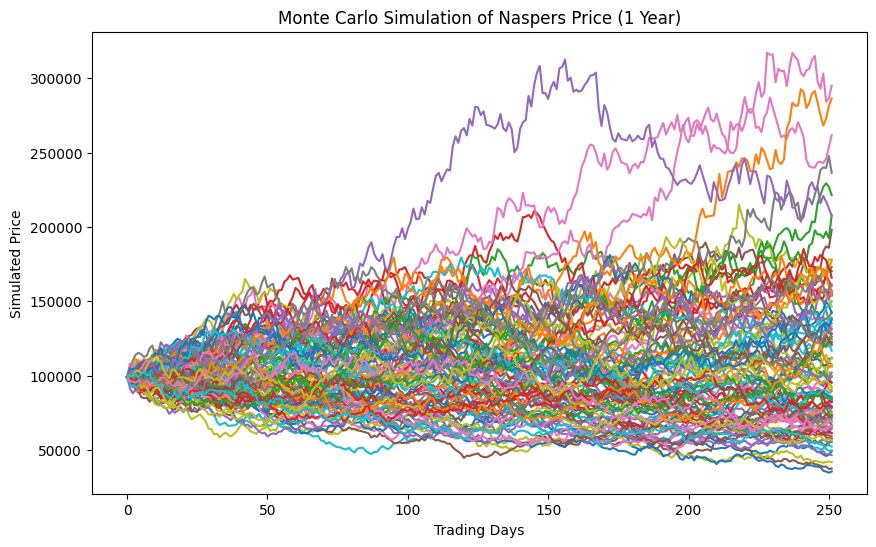

In [ ]:
# ============================================================
# CELL 9: PLOT MONTE CARLO RESULTS
# ============================================================

plt.figure(figsize=(10,6))

# Plot all simulated price paths
plt.plot(price_paths)

plt.title("Monte Carlo Simulation of Naspers Price (1 Year)")
plt.xlabel("Trading Days")
plt.ylabel("Simulated Price")

plt.show()

In [ ]:
# ============================================================
# CELL 10: CALCULATE VALUE AT RISK
# ============================================================

# Extract final simulated prices after 1 year
final_prices = price_paths[-1]

# Calculate 5 percent percentile
VaR_5 = np.percentile(final_prices, 5)

# Compute downside risk in currency terms
value_at_risk = S0 - VaR_5

print("5 Percent Value at Risk (1 Year):", value_at_risk)

5 Percent Value at Risk (1 Year): 49527.17017958998
